<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-CongNguyen/CV-system-/blob/matching-pipeline/Copy_of_resume_extraction_upgraded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🔗 9. CV–Job Matching System (Semantic Cosine Similarity)

**Đây là phần cốt lõi của AI Matching System - thay thế keyword matching đơn giản.**

In [ ]:
import pandas as pd
import re
import nltk
from sentence_transformers import SentenceTransformer, util
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split # Not directly used in this cell, but good practice if df operations change

# NLTK downloads for preprocessing functions
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

def preprocess_basic(txt):
    """Preprocessing cơ bản (giống bản cũ) - dùng cho TF-IDF / word freq."""
    txt = txt.lower()
    txt = re.sub(r'http\S+\s*', ' ', txt)
    txt = re.sub(r'[^a-zA-Z]', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    tokens = nltk.word_tokenize(txt)
    stopwords = set(nltk.corpus.stopwords.words('english'))
    tokens = [w for w in tokens if w not in stopwords and len(w) > 2]
    return ' '.join(tokens)

def preprocess_for_bert(txt, max_words=400):
    """
    Preprocessing nhẹ cho BERT/Sentence-Transformer.
    BERT đã tự tokenize nên KHÔNG nên xóa stopwords.
    Chỉ clean URL, ký tự lạ và cắt bớt độ dài.
    """
    txt = re.sub(r'http\S+\s*', ' ', txt)   # remove URLs
    txt = re.sub(r'[^a-zA-Z0-9\s.,!?-]', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    # Giữ tối đa max_words để tránh quá dài
    words = txt.split()[:max_words]
    return ' '.join(words)

# ===== CẤU HÌNH CẦN THIẾT CHO CELL NÀY =====
SBERT_MODEL = 'all-MiniLM-L6-v2'          # Nhẹ, nhanh, tốt cho semantic similarity
RANDOM_STATE = 42 # For consistency if train_test_split were used here
# ===========================================

# Load dataset (Kaggle: UpdatedResumeDataSet.csv hoặc Resume.csv)
# Thay đổi đường dẫn phù hợp với môi trường của bạn
try:
    df = pd.read_csv('../input/CvsDatasets/ResumeDataSet.csv')
except FileNotFoundError:
    # Demo với dữ liệu giả nếu không có file
    print('  Dataset not found. Creating demo data...')
    demo_data = {
        'Category': ['Data Science', 'Web Designing', 'Java Developer',
                     'Data Science', 'Web Designing', 'Java Developer'] * 10,
        'Resume': [
            'Machine learning engineer with Python TensorFlow experience in deep learning neural networks',
            'Frontend developer skilled in HTML CSS JavaScript React Vue.js responsive design',
            'Java Spring Boot microservices RESTful API backend developer enterprise applications',
            'Data scientist NLP computer vision scikit-learn pandas statistical analysis',
            'UI UX designer Adobe XD Figma prototyping wireframing user interface',
            'Java developer Hibernate Maven SQL database backend systems integration'
        ] * 10
    }
    df = pd.DataFrame(demo_data)

print(f' Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f' Categories: {df["Category"].nunique()} unique classes')

# Tạo 2 phiên bản text cho các mục đích khác nhau
print(' Preprocessing resumes...')
df['Resume_clean']     = df['Resume'].apply(preprocess_basic)      # cho EDA
df['Resume_for_bert']  = df['Resume'].apply(preprocess_for_bert)   # cho BERT/SBERT

# Label encoding (only needed if Category is used, added for completeness)
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Category'])

print(f' Preprocessing done!')

class CVJobMatcher:
    """
    Hệ thống khớp CV với Job Description dùng Sentence-BERT.
    Thay thế keyword overlap bằng semantic cosine similarity.
    """

    def __init__(self, model_name=SBERT_MODEL):
        print(f'Loading matching model: {model_name}...')
        self.model = SentenceTransformer(model_name)
        self.cv_embeddings  = None
        self.cv_texts       = None
        self.cv_metadata    = None
        print(' Matcher ready!')

    def index_resumes(self, resumes_df, text_col='Resume_for_bert', meta_cols=None):
        """Index tất cả resume vào vector store."""
        print(f' Indexing {len(resumes_df)} resumes...')
        self.cv_texts = resumes_df[text_col].tolist()
        self.cv_metadata = resumes_df[meta_cols].to_dict('records') if meta_cols else None
        self.cv_embeddings = self.model.encode(
            self.cv_texts, batch_size=32,
            show_progress_bar=True, convert_to_tensor=True
        )
        print(f'Indexed {len(self.cv_texts)} resumes!')

    def match(self, job_description, top_k=5):
        """
        Tìm top-k resume phù hợp nhất với Job Description.

        Returns: DataFrame với similarity scores và metadata
        """
        # Encode job description
        jd_embedding = self.model.encode(
            preprocess_for_bert(job_description),
            convert_to_tensor=True
        )

        # Tính cosine similarity
        cos_scores = util.cos_sim(jd_embedding, self.cv_embeddings)[0]

        # Lấy top-k
        top_results = torch.topk(cos_scores, k=min(top_k, len(self.cv_texts)))

        results = []
        for score, idx in zip(top_results.values, top_results.indices):
            result = {
                'rank': len(results) + 1,
                'similarity_score': round(float(score), 4),
                'resume_preview': self.cv_texts[idx][:200] + '...'
            }
            if self.cv_metadata:
                result.update(self.cv_metadata[idx])
            results.append(result)

        return pd.DataFrame(results)

    def batch_match(self, job_descriptions, top_k=5):
        """Xử lý nhiều JD cùng lúc."""
        all_results = {}
        for i, jd in enumerate(job_descriptions):
            print(f'Processing JD {i+1}/{len(job_descriptions)}...')
            all_results[f'JD_{i+1}'] = self.match(jd, top_k)
        return all_results


# Khởi tạo matcher
matcher = CVJobMatcher(SBERT_MODEL)
matcher.index_resumes(df, text_col='Resume_for_bert', meta_cols=['Category'])

⚠️  Dataset not found. Creating demo data...
📊 Dataset loaded: 60 rows, 2 columns
📁 Categories: 3 unique classes
🔄 Preprocessing resumes...
✅ Preprocessing done!
🔄 Loading matching model: all-MiniLM-L6-v2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Matcher ready!
🔄 Indexing 60 resumes...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Indexed 60 resumes!


In [ ]:
# Demo matching
sample_jd = """
We are looking for a Senior Data Scientist with 3+ years experience in:
- Python, TensorFlow, PyTorch for deep learning
- NLP and computer vision projects
- Machine learning model deployment
- Statistical analysis and data visualization
- Experience with cloud platforms (AWS/GCP)
"""

print(' Matching JD with resume database...')
top_matches = matcher.match(sample_jd, top_k=5)

print('\n Top 5 Matching Resumes:')
print('=' * 60)
for _, row in top_matches.iterrows():
    print(f"\nRank #{row['rank']} | Score: {row['similarity_score']:.4f}")
    if 'Category' in row:
        print(f"Category: {row['Category']}")
    print(f"Preview: {row['resume_preview'][:150]}...")
    print('-' * 40)

🔍 Matching JD with resume database...

🏆 Top 5 Matching Resumes:

Rank #1 | Score: 0.5738
Category: Data Science
Preview: Machine learning engineer with Python TensorFlow experience in deep learning neural networks......
----------------------------------------

Rank #2 | Score: 0.5738
Category: Data Science
Preview: Machine learning engineer with Python TensorFlow experience in deep learning neural networks......
----------------------------------------

Rank #3 | Score: 0.5738
Category: Data Science
Preview: Machine learning engineer with Python TensorFlow experience in deep learning neural networks......
----------------------------------------

Rank #4 | Score: 0.5738
Category: Data Science
Preview: Machine learning engineer with Python TensorFlow experience in deep learning neural networks......
----------------------------------------

Rank #5 | Score: 0.5738
Category: Data Science
Preview: Machine learning engineer with Python TensorFlow experience in deep learning neural networ

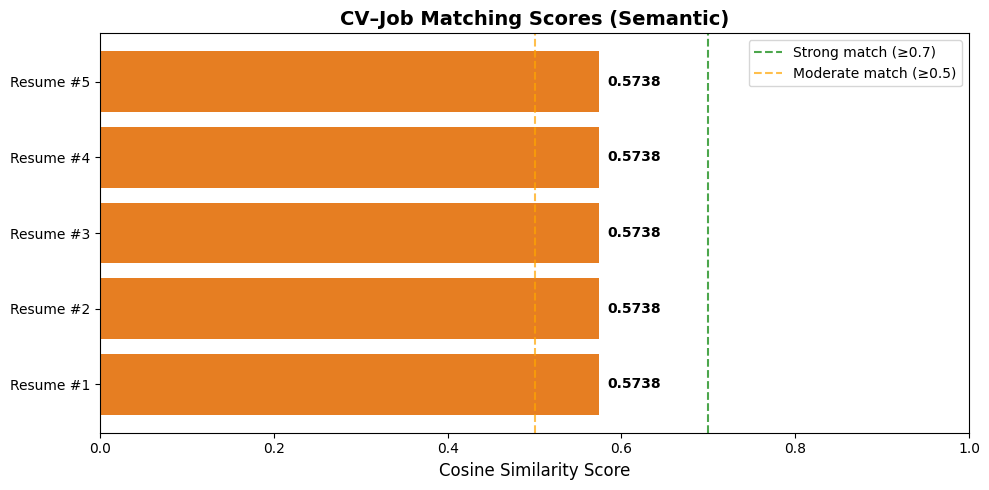

In [ ]:
import matplotlib.pyplot as plt

# Visualize matching scores
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    [f"Resume #{r}" for r in top_matches['rank']],
    top_matches['similarity_score'],
    color=['#2ecc71' if s >= 0.7 else '#e67e22' if s >= 0.5 else '#e74c3c'
           for s in top_matches['similarity_score']]
)
ax.set_xlabel('Cosine Similarity Score', fontsize=12)
ax.set_title('CV–Job Matching Scores (Semantic)', fontsize=14, fontweight='bold')
ax.axvline(0.7, color='green',  linestyle='--', alpha=0.7, label='Strong match (≥0.7)')
ax.axvline(0.5, color='orange', linestyle='--', alpha=0.7, label='Moderate match (≥0.5)')
ax.legend()
ax.set_xlim(0, 1)
for bar, score in zip(bars, top_matches['similarity_score']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()